In [2]:
import cv2
import torch
from insightface.app import FaceAnalysis
from pathlib import Path

from pipeline_insightface import *

app = FaceAnalysis(
    name="buffalo_l",
    providers=["CoreMLExecutionProvider", "CPUExecutionProvider"]
)
app.prepare(ctx_id=0)

Applied providers: ['CoreMLExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CoreMLExecutionProvider': {}}
find model: /Users/sxsthene/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CoreMLExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CoreMLExecutionProvider': {}}
find model: /Users/sxsthene/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CoreMLExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CoreMLExecutionProvider': {}}
find model: /Users/sxsthene/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CoreMLExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CoreMLExecutionProvider': {}}
find model: /Users/sxsthene/.insightface/models/buffalo_l/genderage.onnx 

In [3]:
gallery = {}
gallery_dir = Path("/Users/sxsthene/Documents/Université/Master 1/TER F/reference_photo")

for img_path in gallery_dir.iterdir():
    if img_path.suffix.lower() not in [".jpg", ".png", ".jpeg"]:
        continue

    name = img_path.stem  # identité = nom du fichier

    img = cv2.imread(str(img_path))
    faces = app.get(img)

    if len(faces) == 0:
        print(f"[WARN] Aucun visage détecté dans {img_path.name}")
        continue

    # visage principal (le plus grand)
    face = max(
        faces,
        key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1])
    )

    gallery[name] = build_template(face)

print(f"Galerie prête avec {len(gallery)} personnes")
print("Identités :", list(gallery.keys()))

/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.11/site-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.11/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Galerie prête avec 21 personnes
Identités : ['omia', 'chamss', 'anziza', 'clement', 'lounas', 'sosth', 'moustapha', 'enzo_n', 'yanis', 'enzo_m', 'ayoub', 'melanie', 'rayane', 'anthony_s', 'elhadji', 'cedric', 'louison', 'akil', 'maximiliano', 'samy', 'anthony_ca']


det_score = 0.89257014
bbox size = 190 x 243
det_score = 0.8776504
bbox size = 133 x 178
det_score = 0.7954593
bbox size = 542 x 614
det_score = 0.74307793
bbox size = 285 x 297
[('ayoub', 0.6340404748916626), ('Unknown', 0.08000853657722473), ('Unknown', 0.10015779733657837), ('louison', 0.32725414633750916)]


(-0.5, 4031.5, 3023.5, -0.5)

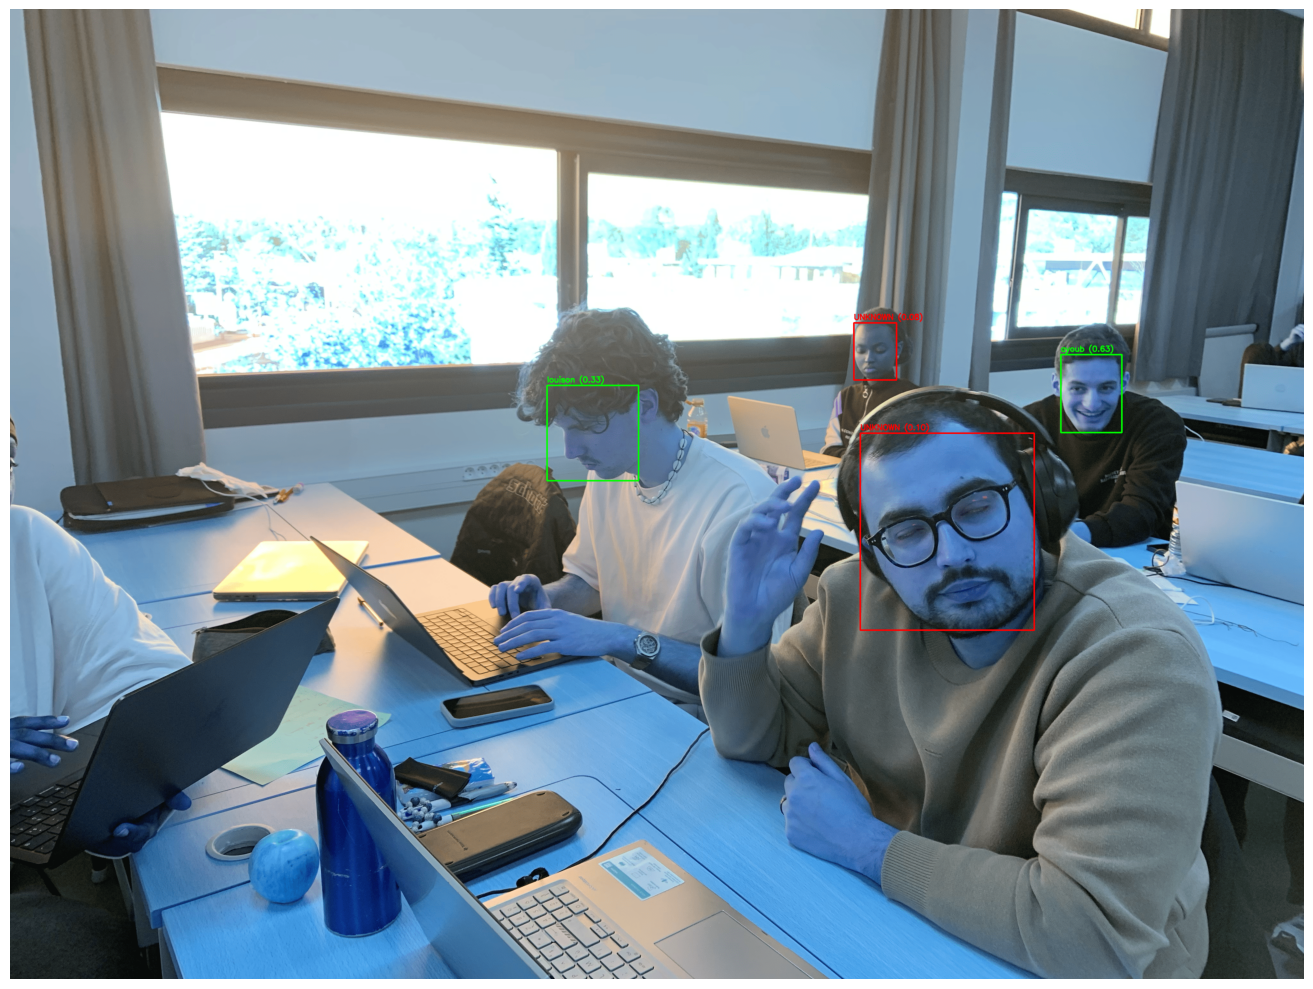

In [14]:
import matplotlib.pyplot as plt

img = cv2.imread("/Users/sxsthene/Documents/Université/Master 1/TER F/query_photo/iloveimg-compressed-4/IMG_3476.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

faces = app.get(img)

results = recognize_image(
    img,
    app,
    gallery,
    threshold=0.3,
    min_score=0.5
)
print(results)

vis = visualize_decision(
    img,
    results,
    faces,
    threshold=0.3
)

plt.imshow(vis)
plt.axis("off")